In [7]:
import sys
sys.path.append('../')
from module.GR.lightray_orbit import path, find_boomerang_b
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

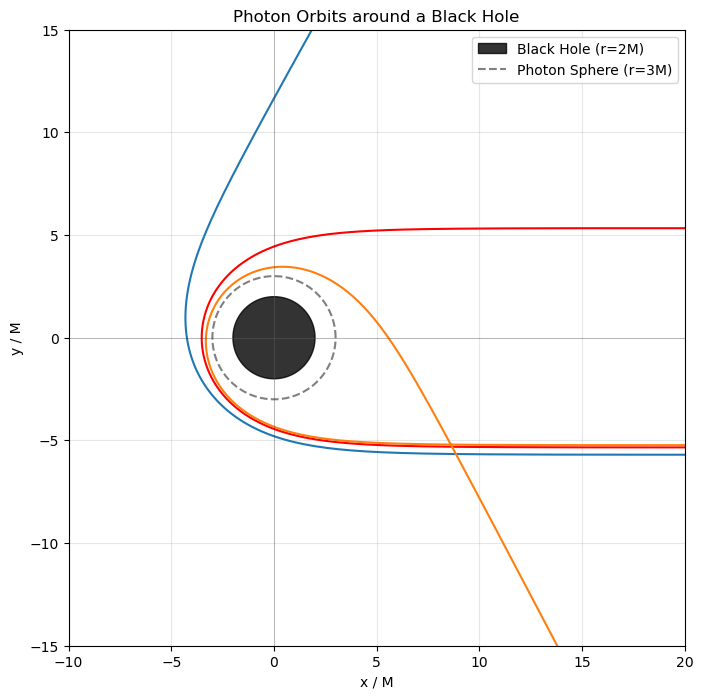

In [ ]:
M = 1.0
b_critical = np.sqrt(27) * M
rtol = 1e-13
atol = 1e-15
plt.figure(figsize=(8, 8))

x_circ, y_circ = path(b=b_critical*(1+1e-1), M=M, phi_max=10*np.pi, rtol=rtol, atol=atol)
plt.plot(x_circ, y_circ)

x_circ, y_circ = path(b=b_critical*(1+0.0309), M=M, phi_max=10*np.pi, rtol=rtol, atol=atol)
plt.plot(x_circ, y_circ, color='red')

x_circ, y_circ = path(b=b_critical*(1+1e-2), M=M, phi_max=10*np.pi, rtol=rtol, atol=atol)
plt.plot(x_circ, y_circ)

theta = np.linspace(0, 2*np.pi, 100)
bh_x = 2 * M * np.cos(theta)
bh_y = 2 * M * np.sin(theta)
plt.fill(bh_x, bh_y, color='black', alpha=0.8, label='Black Hole (r=2M)')

ps_x = 3 * M * np.cos(theta)
ps_y = 3 * M * np.sin(theta)
plt.plot(ps_x, ps_y, color='gray', linestyle='--', label='Photon Sphere (r=3M)')

plt.xlim(-10, 20)
plt.ylim(-15, 15)
plt.xlabel("x / M")
plt.ylabel("y / M")
plt.title("Photon Orbits around a Black Hole")
plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

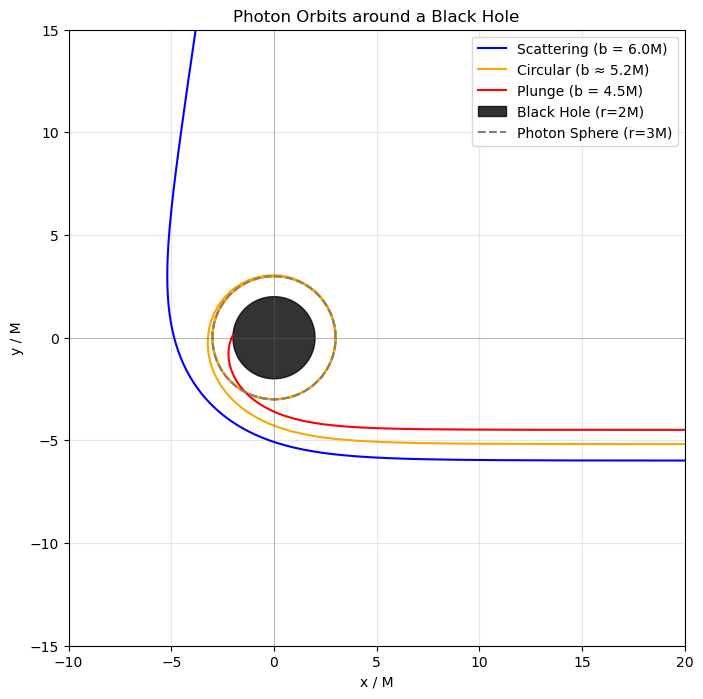

In [ ]:
M = 1.0
b_critical = np.sqrt(27) * M
rtol = 1e-13
atol = 1e-15
plt.figure(figsize=(8, 8))

x_scat, y_scat = path(b=6.0 * M, M=M, rtol=rtol, atol=atol)
plt.plot(x_scat, y_scat, label=f'Scattering (b = 6.0M)', color='blue')

x_circ, y_circ = path(b=b_critical, M=M, phi_max=8*np.pi, rtol=rtol, atol=atol)
plt.plot(x_circ, y_circ, label=f'Circular (b ≈ 5.2M)', color='orange')

x_plunge, y_plunge = path(b=4.5 * M, M=M, rtol=rtol, atol=atol)
plt.plot(x_plunge, y_plunge, label=f'Plunge (b = 4.5M)', color='red')

theta = np.linspace(0, 2*np.pi, 100)
bh_x = 2 * M * np.cos(theta)
bh_y = 2 * M * np.sin(theta)
plt.fill(bh_x, bh_y, color='black', alpha=0.8, label='Black Hole (r=2M)')

ps_x = 3 * M * np.cos(theta)
ps_y = 3 * M * np.sin(theta)
plt.plot(ps_x, ps_y, color='gray', linestyle='--', label='Photon Sphere (r=3M)')

plt.xlim(-10, 20)
plt.ylim(-15, 15)
plt.xlabel("x / M")
plt.ylabel("y / M")
plt.title("Photon Orbits around a Black Hole")
plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Generating animation frames...
Saving to ../videos/GR/light_orbit.gif...
Saved successfully!


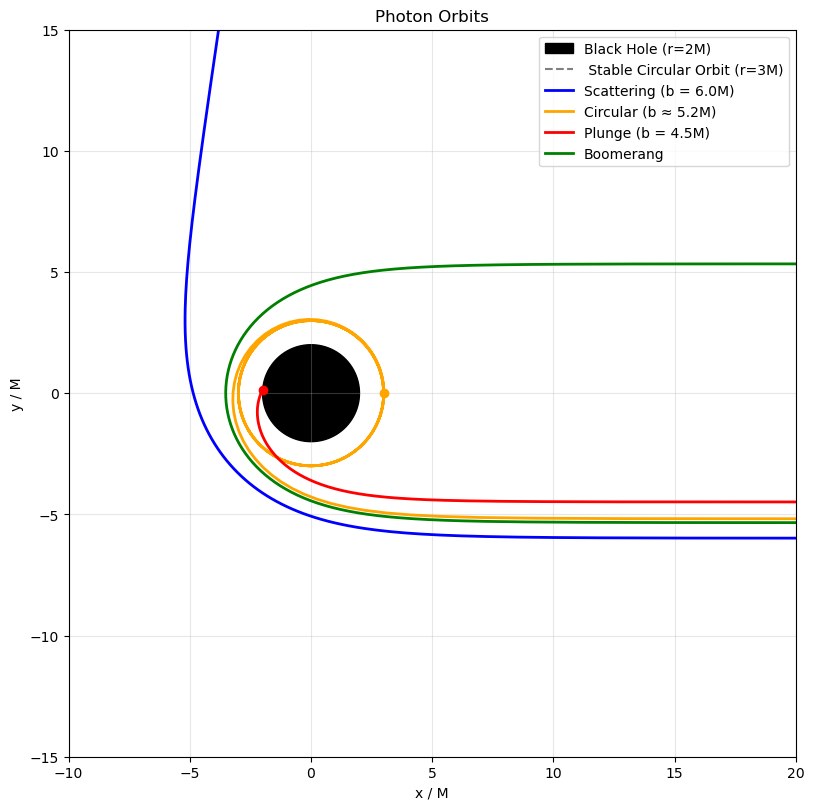

In [ ]:
M = 1.0 
b_critical = np.sqrt(27) * M 
TOTAL_FRAMES = 200
rtol=2.5e-14
atol=1e-15

x_scat, y_scat = path(6.0 * M, M, num_points=TOTAL_FRAMES, rtol=rtol, atol=atol)
x_circ, y_circ = path(b_critical, M, num_points=TOTAL_FRAMES, rtol=rtol, atol=atol)
x_plunge, y_plunge = path(4.5 * M, M, num_points=TOTAL_FRAMES, rtol=rtol, atol=atol)
x_boomerang, y_boomerang = path(b_critical*(1+0.0309), M, num_points=TOTAL_FRAMES, rtol=rtol, atol=atol)

fig, ax = plt.subplots(figsize=(8, 8))
fig.tight_layout()
ax.set_xlim(-10, 20)
ax.set_ylim(-15, 15)
ax.set_xlabel("x / M")
ax.set_ylabel("y / M")
ax.set_title("Photon Orbits")
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')

theta = np.linspace(0, 2*np.pi, 100)
ax.fill(2 * M * np.cos(theta), 2 * M * np.sin(theta), color='black', label='Black Hole (r=2M)')
ax.plot(3 * M * np.cos(theta), 3 * M * np.sin(theta), color='gray', linestyle='--', label=' Stable Circular Orbit (r=3M)')

line_scat, = ax.plot([], [], label=f'Scattering (b = 6.0M)', color='blue', linewidth=2)
line_circ, = ax.plot([], [], label=f'Circular (b ≈ 5.2M)', color='orange', linewidth=2)
line_plunge, = ax.plot([], [], label=f'Plunge (b = 4.5M)', color='red', linewidth=2)
line_boomerang, = ax.plot([], [], label=f'Boomerang', color='green', linewidth=2)

head_scat, = ax.plot([], [], 'o', color='blue')
head_circ, = ax.plot([], [], 'o', color='orange')
head_plunge, = ax.plot([], [], 'o', color='red')
head_boomerang, = ax.plot([], [], 'o', color='green')

ax.legend(loc="upper right")

def init():
    line_scat.set_data([], [])
    line_circ.set_data([], [])
    line_plunge.set_data([], [])
    line_boomerang.set_data([], [])
    head_scat.set_data([], [])
    head_circ.set_data([], [])
    head_plunge.set_data([], [])
    head_boomerang.set_data([], [])
    return line_scat, line_circ, line_plunge, line_boomerang, head_scat, head_circ, head_plunge, head_boomerang

def update(frame):
    # Update trails
    line_scat.set_data(x_scat[:frame+1], y_scat[:frame+1])
    line_circ.set_data(x_circ[:frame+1], y_circ[:frame+1])
    line_plunge.set_data(x_plunge[:frame+1], y_plunge[:frame+1])
    line_boomerang.set_data(x_boomerang[:frame+1], y_boomerang[:frame+1])
    
    # Update leading "photon" dots
    head_scat.set_data([x_scat[frame]], [y_scat[frame]])
    head_circ.set_data([x_circ[frame]], [y_circ[frame]])
    head_plunge.set_data([x_plunge[frame]], [y_plunge[frame]])
    head_boomerang.set_data([x_boomerang[frame]], [y_boomerang[frame]])
    
    return line_scat, line_circ, line_plunge, line_boomerang, head_scat, head_circ, head_plunge, head_boomerang

print("Generating animation frames...")
ani = FuncAnimation(fig, update, frames=TOTAL_FRAMES, init_func=init, blit=True)

save_path = '../videos/GR/light_orbit.gif'
print(f"Saving to {save_path}...")
ani.save(save_path, writer=PillowWriter(fps=30))
print("Saved successfully!")

plt.show()